In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.config import PROCESSED, SPLITS, FIGURES, RANDOM_STATE
from src.cv import load_fold_table, make_fold_table
from src.data import feature_cols
from src.evaluate import cross_validate

dev = pd.read_csv(PROCESSED / "dev_2v3.csv")
table = load_fold_table()                                   # twin-group folds
groups = pd.read_csv(SPLITS / "groups.csv").set_index("segment")["group"]
hold_ids = set(pd.read_csv(SPLITS / "holdout_segments.csv")["segment"])

assert set(dev["segment"]) == set(table["segment"])
assert set(dev["segment"]).isdisjoint(hold_ids)
assert set(groups[list(hold_ids)]).isdisjoint(set(groups[dev["segment"].unique()]))
print("splits are consistent:", dev["segment"].nunique(), "dev segments,", len(hold_ids), "hold-out segments")

cols = feature_cols(dev)
X = dev[cols].to_numpy(dtype=float)
Xc = X - X.mean(axis=1, keepdims=True)
Z = Xc / Xc.std(axis=1, keepdims=True)                                   # level and spread removed
power = np.abs(np.fft.rfft(Xc, axis=1))[:, 1:] ** 2
S = np.log(power / power.sum(axis=1, keepdims=True) + 1e-9)              # relative log spectrum, 89 numbers

splits are consistent: 160 dev segments, 40 hold-out segments


In [2]:
forest = lambda: RandomForestClassifier(50, random_state=RANDOM_STATE, n_jobs=-1)
runs = {
    "chance (predicts the class prior)": (X, lambda: DummyClassifier(strategy="prior")),
    "logistic regression, raw values": (X, lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    "random forest, raw values": (X, forest),
    "random forest, level and spread removed": (Z, forest),
    "KNN (k=25), level and spread removed": (Z, lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(25))),
    "logistic regression, relative log spectrum": (S, lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
}

table_seg = make_fold_table(dev)                            # the old design: folds of single segments
results = {"twin-group folds": {}, "plain segment folds": {}}
for name, (F, make_model) in runs.items():
    results["twin-group folds"][name] = cross_validate(make_model, dev, F, table)
    results["plain segment folds"][name] = cross_validate(make_model, dev, F, table_seg)

summary = pd.DataFrame({design: {name: r["auc_fold"].mean() for name, r in res.items()}
                        for design, res in results.items()}).round(3)
summary["drop"] = (summary["plain segment folds"] - summary["twin-group folds"]).round(3)
summary

,twin-group folds,plain segment folds,drop
chance (predicts the class prior),0.500,0.500,0.000
"logistic regression, raw values",0.334,0.572,0.238
"random forest, raw values",0.580,0.826,0.246
"random forest, level and spread removed",0.613,0.930,0.317
"KNN (k=25), level and spread removed",0.629,0.869,0.240
"logistic regression, relative log spectrum",0.635,0.745,0.110


In [3]:
detail = pd.DataFrame({name: {"AUC sd": r["auc_fold"].std(), "accuracy": r["accuracy"].mean(),
                              "TP": r["tp"].mean(), "FN": r["fn"].mean(),
                              "FP": r["fp"].mean(), "TN": r["tn"].mean()}
                       for name, r in results["twin-group folds"].items()}).T.round(3)
detail

,AUC sd,accuracy,TP,FN,FP,TN
chance (predicts the class prior),0.000,0.488,14.0,66.0,16.0,64.0
"logistic regression, raw values",0.033,0.411,17.0,63.0,31.2,48.8
"random forest, raw values",0.020,0.539,33.8,46.2,27.6,52.4
"random forest, level and spread removed",0.039,0.570,26.4,53.6,15.2,64.8
"KNN (k=25), level and spread removed",0.022,0.600,19.0,61.0,3.0,77.0
"logistic regression, relative log spectrum",0.020,0.602,44.8,35.2,28.4,51.6


In [4]:
log_spec = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
seg_group = dev.groupby("segment")["y"].first().to_frame().join(groups)
group_class = seg_group.groupby("group")["y"].agg(lambda s: s.value_counts().idxmax())   # each group's class
group_size = seg_group.groupby("group").size()

chance_aucs, s = [], 0
while len(chance_aucs) < 30:
    rng = np.random.default_rng(100 + s)
    s += 1
    shuffled = pd.Series(rng.permutation(group_class.values), index=group_class.index)    # labels shuffled between groups
    if abs(group_size[shuffled == 2].sum() - 80) > 4:        # keep the classes about balanced, like the real labels
        continue
    d = dev.copy()
    d["y"] = d["segment"].map(groups).map(shuffled)
    chance_aucs.append(cross_validate(log_spec, d, S, table, n_repeats=1)["auc_fold"].iloc[0])

lo, hi = np.percentile(chance_aucs, [5, 95])
print("AUC with shuffled labels, 30 draws: 5th to 95th percentile", round(lo, 2), "to", round(hi, 2),
      "| mean", round(np.mean(chance_aucs), 3))

AUC with shuffled labels, 30 draws: 5th to 95th percentile 0.32 to 0.6 | mean 0.461


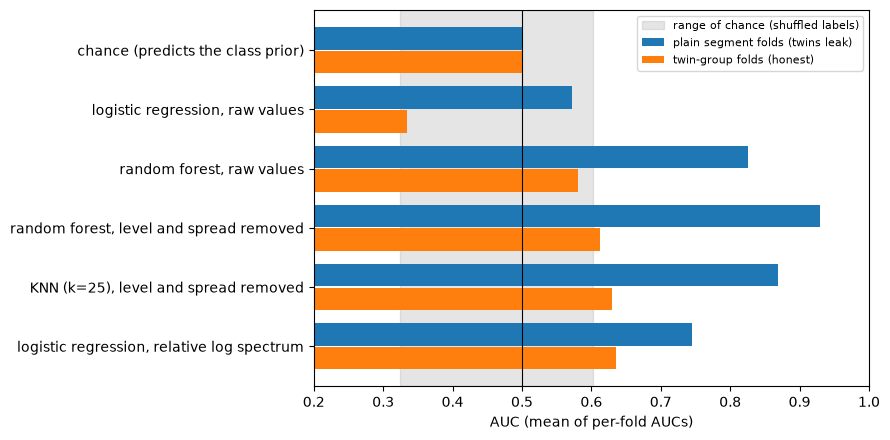

In [5]:
order = list(summary.index[::-1])
fig, ax = plt.subplots(figsize=(9, 4.5))
yy = np.arange(len(order))
ax.axvspan(lo, hi, color="grey", alpha=0.2, label="range of chance (shuffled labels)")
ax.barh(yy + 0.2, summary.loc[order, "plain segment folds"], height=0.38, label="plain segment folds (twins leak)")
ax.barh(yy - 0.2, summary.loc[order, "twin-group folds"], height=0.38, label="twin-group folds (honest)")
ax.set_yticks(yy)
ax.set_yticklabels(order)
ax.axvline(0.5, color="black", lw=0.8)
ax.set_xlabel("AUC (mean of per-fold AUCs)")
ax.set_xlim(0.2, 1.0)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "07_leak_effect.png", dpi=150)
plt.show()

# 07 Honest baselines

Same six models and the same dev data, scored two ways: plain segment folds (the old design, where twins can leak) and twin-group folds (the corrected design). Metric: mean of per-fold AUCs, 5 repeats.

| Model | Plain segment folds | Twin-group folds | Drop |
|---|---|---|---|
| Chance | 0.500 | 0.500 | 0.000 |
| Logistic regression, raw values | 0.572 | 0.332 | 0.240 |
| Random forest, raw values | 0.826 | 0.580 | 0.246 |
| Random forest, level and spread removed | 0.930 | 0.613 | 0.317 |
| KNN (k=25), level and spread removed | 0.869 | 0.629 | 0.240 |
| Logistic regression, relative log spectrum | 0.745 | 0.635 | 0.110 |

Range of chance on the twin-group folds (shuffled labels, 30 draws): 0.32 to 0.60, mean 0.46.

## Findings
- Fold design alone moves the scores by 0.11 to 0.32 AUC.
- On honest folds, the raw-value models are inside the chance range.
- The three best models (0.61 to 0.64) sit just above the top of it. That hints at a weak signal, but it is not proof, and some remaining similarity between segments could explain it.
- The shuffled-label mean is 0.46, not 0.50. Leaving out whole groups pulls a model with nothing to learn slightly below chance.

## Caveats
- The chance range comes from one model (logistic on the spectrum) and 30 draws.
- Differences below about 0.05 are within noise.